# Esse é o tratamento de todos os arquivos


## Carregando as variáveis de ambiente
*Estou carregando pelo pandas e não pelo numpy. Por que? Porque eu quero!*

In [1]:
import pandas as pd
import numpy as np
import filter as ft
import IPython.display as dsp
import seaborn as sn
import utils2 as ut
from pathlib import Path
from datetime import datetime
from configuration_new import Configuration

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


## Criando as variáveis iniciais

In [2]:
cfg = Configuration()
path_data = "data/"
meta_file = "data/meta.xlsx"
path_output =  'output'
path_output =  f"output_{datetime.now():%Y_%m_%d_%H_%M_%S}/"
path_output =  f"processado/"
output = Path(path_output)
output.mkdir(parents=True, exist_ok=True)
loaded_files = {} #recs
filtered_data = {}
raw_data = {}
failures=[]
sampling_verification = [ ]# fsv_rows
quality_control, profiles_rows = [], []
selection_criterion = "55 registros de repouso do experimento de 3 eletrodos do MODMA, lote completo, sem seleção adicional."

## Carregando arquivos e informações do dataset (metadados)

In [3]:
metadata = ut.load_modma_metadata(meta_file)
files, failures_files = ut.discover_eeg_txt_files(path_data)

## Fazendo a análise dos arquivos

In [4]:
for file in files:
    try:
        
        rec, data_raw = ut.load_modma_to_save(file,cfg, file.name)
        # dsp.display(data_raw)
        fsv = ut.verify_sampling_rate(data_raw, cfg)
        rec = rec|fsv
        
        fsv['subject_id'] = rec['subject_id']
        sampling_verification.append(fsv)
        # print(rec)
        subject_id, subject_state = [rec['subject_id'], rec['task_parsed']]
        data_raw = pd.read_csv(file, sep=" ", names=cfg.electrode_labels)
        data_raw = np.transpose(data_raw.to_numpy().astype(float)) #Convertendo os dados para np.ndarray
        data_np, changed_values_on_wraparound = ft.fix_integer_wraparound(data_raw)
        data_np = np.ascontiguousarray(data_np)
        data_np, filter_info = ft.apply_filter(data_np, cfg) 
        filtered_data[subject_id] = data_np
        profile = ut.spectral_profile_blocked(data_np, cfg.sampling_frequency, cfg.block_time)
        profile['subject_id'] = subject_id
        profile['task'] = subject_state
        metrics = ut.quality_control_metrics(data_raw, data_np, filtering_info=filter_info, subject_id=subject_id, file_name=file.name, eeg_task=subject_state, n_wraparound=changed_values_on_wraparound)
        # salvar_profile(profile, output)
        # salvar_filtered_data(data_np, output)
        rec = rec | metrics
        loaded_files[rec['subject_id']] = rec
    except Exception as error:
        print(f"Failed to process file {file.name}: {error}")
        failures_files.append({
                "file": file.name, 
                "subject_id": file.stem.split("_")[0],
                "stage": "read_or_profile",
                 "error": "%s: %s" % (type(error).__name__, str(error)[:200])})

In [8]:
loaded_files_df = pd.DataFrame.from_dict(loaded_files, orient="index").reset_index(drop=True)

metadata_loaded = metadata.merge(
    loaded_files_df,
    on="subject_id",
    how="left",
    validate="one_to_one"
)

metadata_loaded.head()

,subject_id,label,label_raw,age,sex,education_years,id_prefix,n_samples,duration_s,n_wraparound_fixed,wraparound_fraction,dc_offset_counts,task_parsed,implied_fs_if_peak_is_line_hz,fs_assumed_hz,fs_is_assumption,line_peak_hz_under_assumed_fs,line_peak_prominence_log10,fs_verification,fs_supported,source_name,task,finite,flat_channels,saturation_fraction,zero_diff_fraction,line_noise_ratio_raw,line_noise_ratio_post,notch_applied,ocular_index,muscle_ratio,nonstationarity_cv,min_channel_corr,rms_counts,log_rms_counts
0,02010002,1,MDD,18,0.0,12,0201,298260,1193.040,0,0.0,"[4941408.524800509, 4972749.487745591, 4772156...",still,"[250.0, 300.0]",250.0,True,50.0,6.398654,line_peak_at_expected_frequency,True,02010002_still.txt,still,True,0,0.0,0.000009,835.977175,0.000286,True,0.422666,0.075356,0.783745,0.740264,442.282473,2.645700
1,02010005,1,MDD,20,1.0,16,0201,294409,1177.636,0,0.0,"[4536627.673736197, 4778848.264825464, 4639434...",still,"[250.0, 300.0]",250.0,True,50.0,5.010928,line_peak_at_expected_frequency,True,02010005_still.txt,still,True,0,0.0,0.000058,44.835857,0.000039,True,0.686378,0.044868,1.639146,0.852388,792.401694,2.898945
2,02010006,1,MDD,42,1.0,16,0201,301468,1205.872,0,0.0,"[4238315.657930527, 4263657.932775618, 4151116...",still,"[250.0, 300.0]",250.0,True,50.0,6.140425,line_peak_at_expected_frequency,True,02010006_still.txt,still,True,0,0.0,0.000013,738.611386,0.000099,True,0.502529,0.086076,4.704563,0.440884,650.673447,2.813363
3,02010007,1,MDD,32,0.0,12,0201,306072,1224.288,0,0.0,"[4032361.9728919994, 4815687.273102407, 510030...",still,"[250.0, 300.0]",250.0,True,50.0,5.893209,line_peak_at_expected_frequency,True,02010007_still.txt,still,True,0,0.0,0.000025,205.336204,0.000127,True,0.352931,0.073662,2.149367,0.856803,595.913161,2.775183
4,02010008,1,MDD,42,1.0,12,0201,300859,1203.436,0,0.0,"[4207070.96062275, 4212773.535250732, 4159030....",still,"[250.0, 300.0]",250.0,True,50.0,6.422160,line_peak_at_expected_frequency,True,02010008_still.txt,still,True,0,0.0,0.000016,575.940071,0.000071,True,0.493178,0.061383,0.429606,0.924952,529.666236,2.724002


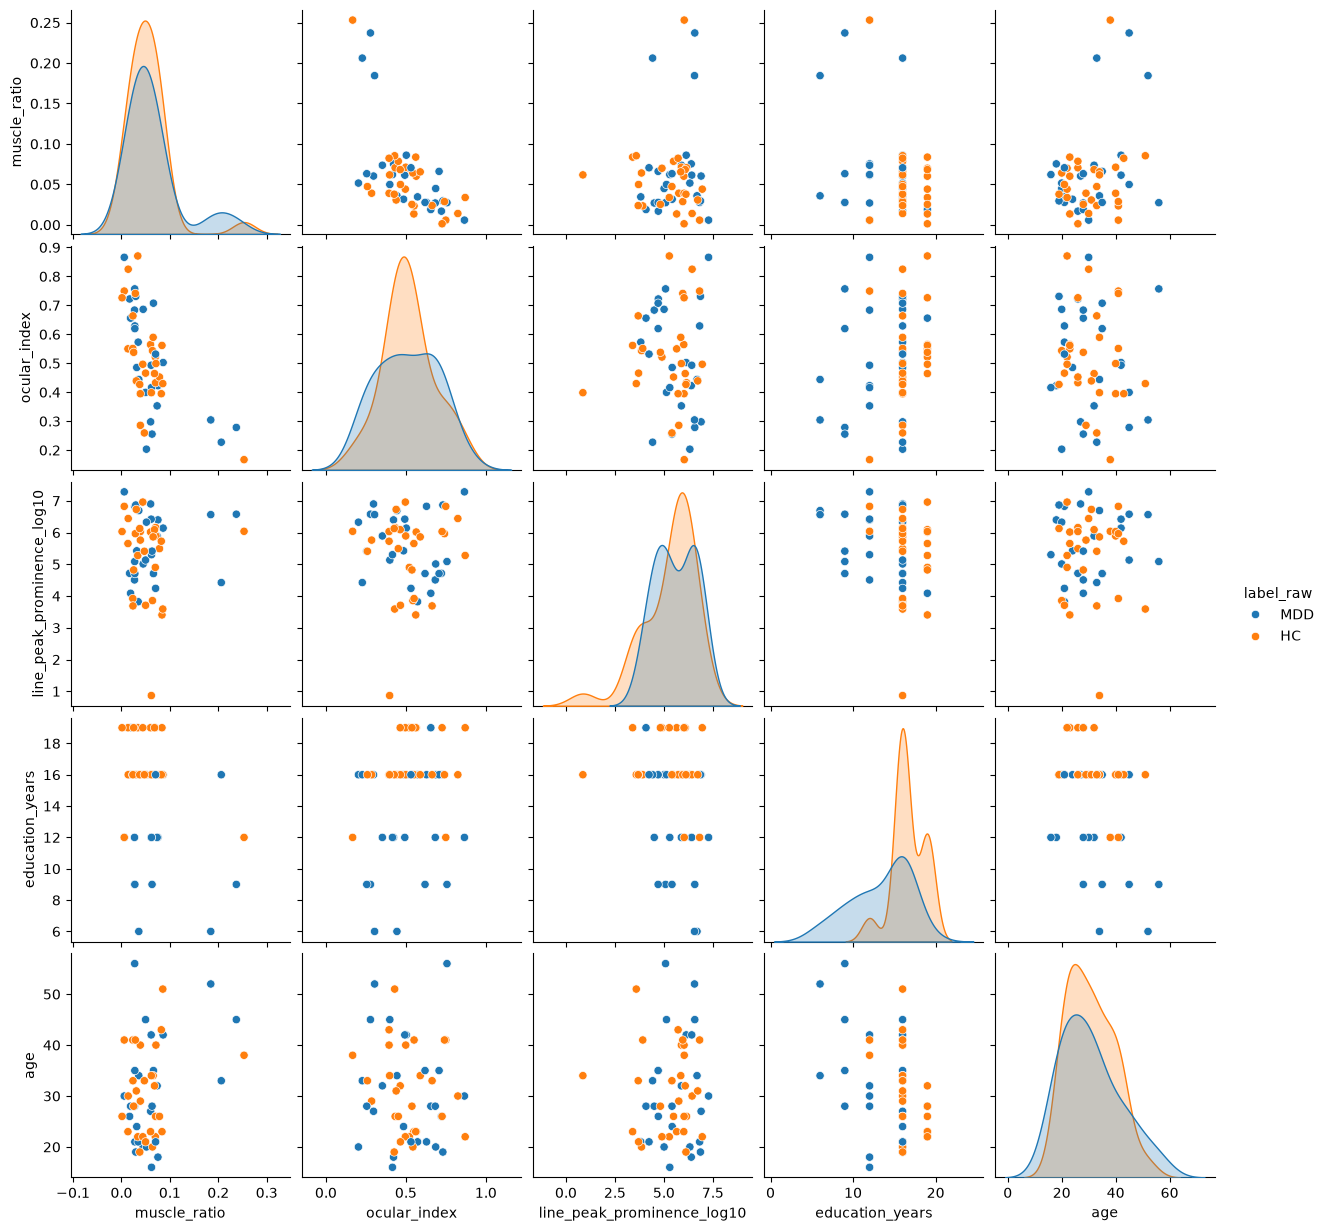

In [21]:
# print(loaded_files_df.columns)
sn.pairplot(metadata_loaded, hue="label_raw", vars=['muscle_ratio', 'ocular_index', 'line_peak_prominence_log10', "education_years", "age"])
# dsp.display(pd.DataFrame(loaded_files))
# dsp.display((profiles_rows))
# dsp.display(pd.DataFrame(loaded_files))
